In [1]:
!pip install tensorflowjs
import tensorflowjs as tfjs
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.0 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
db-dtypes 1.4.3 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.34.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


In [2]:
## 1. Data Preparation
DATA_FILE = 'stroke_data.csv'

try:
    df = pd.read_csv(DATA_FILE)
    print(f"Data berhasil dimuat dari {DATA_FILE}")
except FileNotFoundError:
    print(f"Error: File '{DATA_FILE}' tidak ditemukan.")
    sys.exit()

print("Data Awal (Head)")
print(df.head())
print("Informasi Data")
df.info()
print("Statistik Deskriptif")
print(df.describe())

Data berhasil dimuat dari stroke_data.csv
Data Awal (Head)
   sex   age  hypertension  heart_disease  ever_married  work_type  \
0  1.0  63.0             0              1             1          4   
1  1.0  42.0             0              1             1          4   
2  0.0  61.0             0              0             1          4   
3  1.0  41.0             1              0             1          3   
4  1.0  85.0             0              0             1          4   

   Residence_type  avg_glucose_level   bmi  smoking_status  stroke  
0               1             228.69  36.6               1       1  
1               0             105.92  32.5               0       1  
2               1             171.23  34.4               1       1  
3               0             174.12  24.0               0       1  
4               1             186.21  29.0               1       1  
Informasi Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40910 entries, 0 to 40909
Data columns (t

Jumlah Nilai Hilang (NaN) per Kolom Awal
sex                  3
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Mengisi 0 missing values di kolom 'sex' dengan modus: 1.0

--- Jumlah Nilai Hilang (NaN) per Kolom Setelah Penanganan ---
sex                  0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64
Semua nilai NaN telah berhasil ditangani.

Jumlah baris duplikat: 1
Jumlah baris setelah menghapus duplikat: 40909
Distribusi Variabel Target


<ipython-input-3-d6abd9de1738>:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sex'].fillna(mode_value, inplace=True)


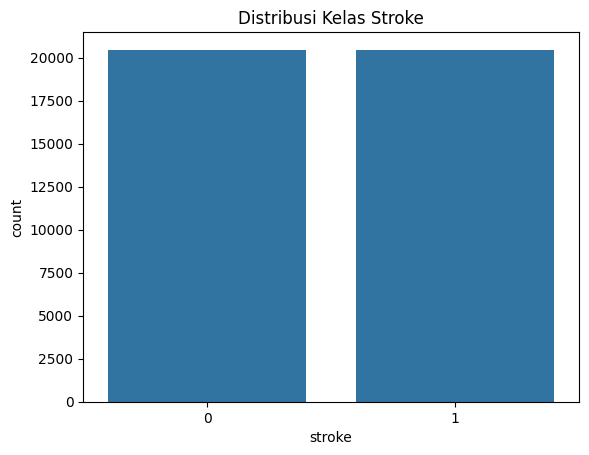

Korelasi antar Fitur Numerik dan Target


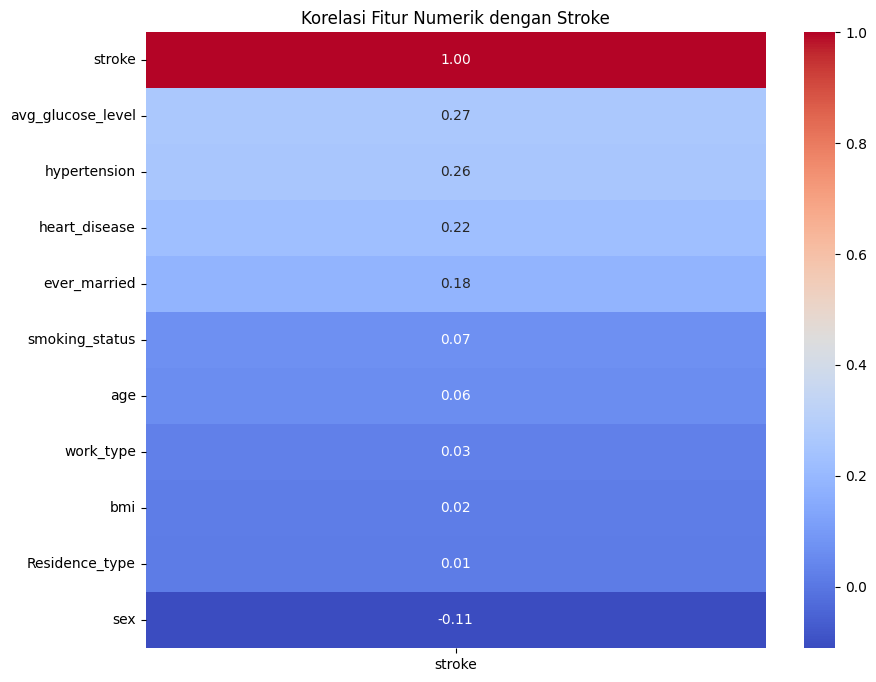

<ipython-input-3-d6abd9de1738>:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='viridis')
<ipython-input-3-d6abd9de1738>:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='viridis')
<ipython-input-3-d6abd9de1738>:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='viridis')


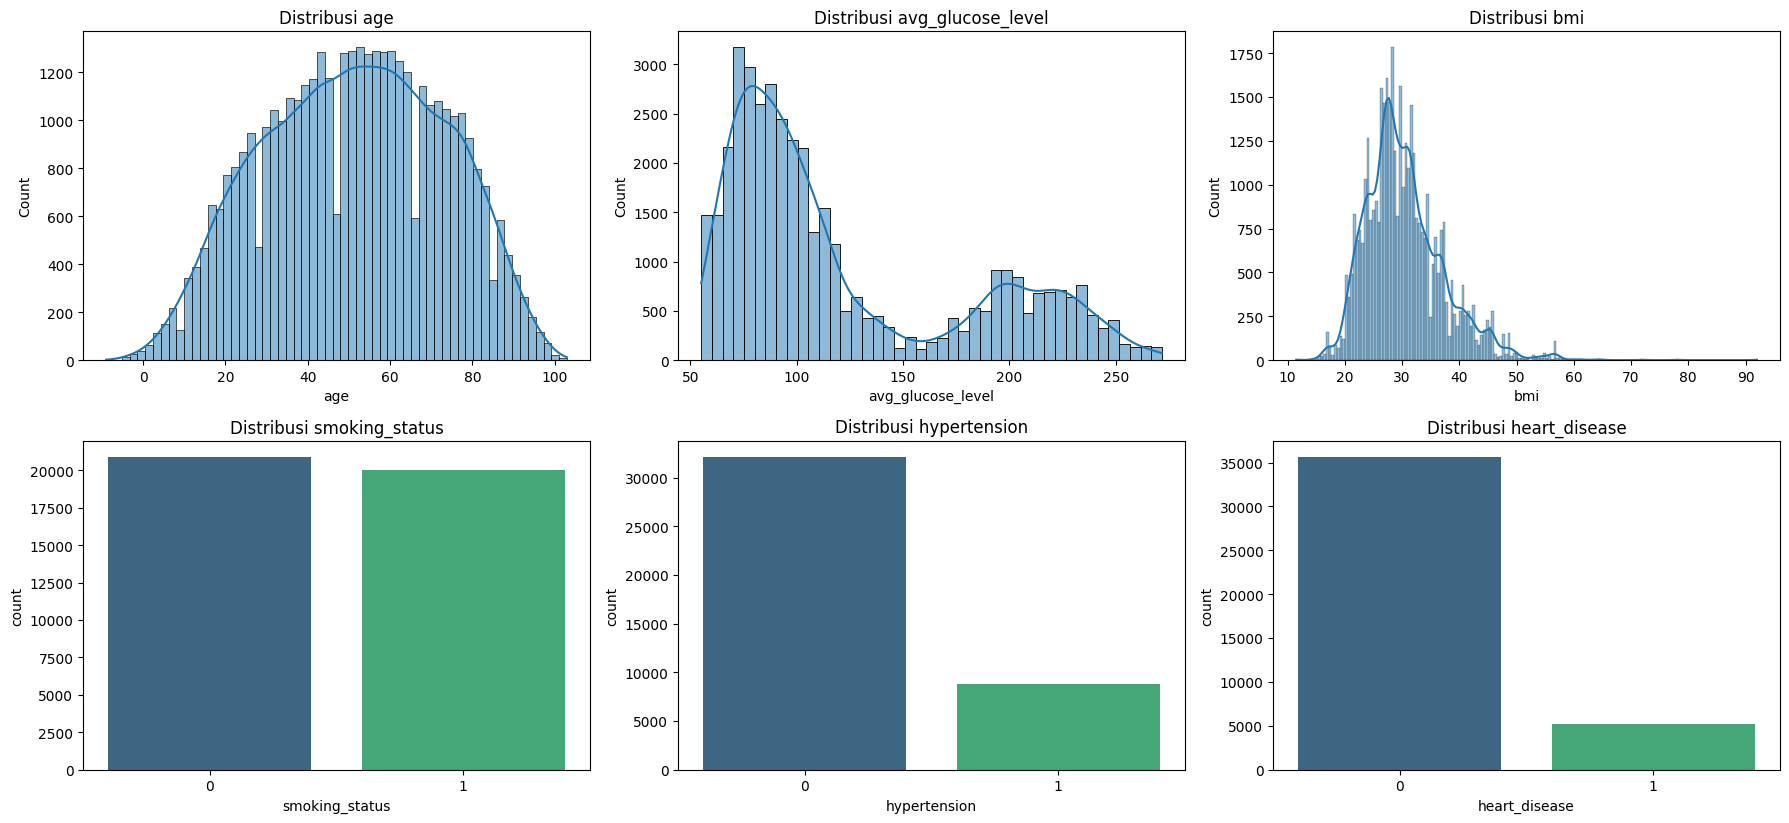

In [3]:
# 2. Exploratory Data Analysis (EDA) & Data Cleaning

print("Jumlah Nilai Hilang (NaN) per Kolom Awal")
print(df.isnull().sum())

if 'stroke' not in df.columns:
    print("\nError: Kolom 'stroke' tidak ditemukan di dataset")
    print(f"Kolom yang tersedia: {df.columns.tolist()}")
    sys.exit()

initial_rows = len(df)
df.dropna(subset=['stroke'], inplace=True)
if initial_rows != len(df):
    print(f"Menghapus {initial_rows - len(df)} baris karena 'stroke' mengandung NaN.")

# Penanganan missing value untuk kolom 'sex'
if 'sex' in df.columns:
    if df['sex'].isnull().any():
        # Cek apakah ada nilai yang valid untuk dijadikan mode
        if len(df['sex'].mode()) > 0:
            mode_value = df['sex'].mode()[0]
            df['sex'].fillna(mode_value, inplace=True)
            print(f"\nMengisi {df['sex'].isnull().sum()} missing values di kolom 'sex' dengan modus: {mode_value}")
        else:
            print("\nPeringatan: Kolom 'sex' tidak memiliki nilai valid untuk dijadikan modus")
            df.drop('sex', axis=1, inplace=True)
            print("Kolom 'sex' dihapus karena semua nilai null")
else:
    print("\nKolom 'sex' tidak ditemukan dalam dataset")

print("\n--- Jumlah Nilai Hilang (NaN) per Kolom Setelah Penanganan ---")
print(df.isnull().sum())
if df.isnull().sum().sum() == 0:
    print("Semua nilai NaN telah berhasil ditangani.")
else:
    print("Masih ada NaN di beberapa kolom. Periksa kembali.")

# Periksa duplikat
if 'id' in df.columns:
    df_no_id = df.drop('id', axis=1)
    print(f"\nJumlah baris duplikat (tidak termasuk 'id'): {df_no_id.duplicated().sum()}")
    df.drop_duplicates(subset=[col for col in df.columns if col != 'id'], inplace=True)
else:
    print(f"\nJumlah baris duplikat: {df.duplicated().sum()}")
    df.drop_duplicates(inplace=True)
print(f"Jumlah baris setelah menghapus duplikat: {len(df)}")

print("Distribusi Variabel Target")
sns.countplot(x='stroke', data=df)
plt.title('Distribusi Kelas Stroke')
plt.show()

if df['stroke'].value_counts(normalize=True).min() < 0.1: # Jika kelas minoritas kurang dari 10%
    print("\nPeringatan: Dataset ini mungkin memiliki ketidakseimbangan kelas yang signifikan")
    print("Pertimbangkan teknik penanganan ketidakseimbangan kelas (misal: SMOTE) setelah splitting data")

print("Korelasi antar Fitur Numerik dan Target")
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'stroke' in numeric_cols:
    numeric_cols.remove('stroke')

if len(numeric_cols) > 0:
    correlation_matrix = df[numeric_cols + ['stroke']].corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix[['stroke']].sort_values(by='stroke', ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Korelasi Fitur Numerik dengan Stroke')
    plt.show()
else:
    print("Tidak ada fitur numerik yang tersisa untuk menghitung korelasi.")

# Distribusi beberapa fitur penting
eda_features = ['age', 'avg_glucose_level', 'bmi', 'gender', 'smoking_status', 'hypertension', 'heart_disease']
plt.figure(figsize=(18, 12))
plot_idx = 1
for feature in eda_features:
    if feature in df.columns:
        plt.subplot(3, 3, plot_idx)
        if df[feature].dtype == 'object' or df[feature].nunique() < 15:
            sns.countplot(x=feature, data=df, palette='viridis')
        else:
            sns.histplot(df[feature], kde=True)
        plt.title(f'Distribusi {feature}')
        plot_idx += 1
plt.tight_layout()
plt.show()

In [4]:
# 3. Feature Engineering & Preprocessing
# Define features (X) and target (y)
X = df.drop('stroke', axis=1)
y = df['stroke']

if 'id' in X.columns:
    X = X.drop('id', axis=1)
    print("\nKolom 'id' dihapus dari fitur.")

# Hapus fitur yang tidak diperlukan/tidak relevan
features_to_drop_actual = ['sex']
features_to_drop = [f for f in features_to_drop_actual if f in X.columns]
if features_to_drop:
    X = X.drop(columns=features_to_drop, errors='ignore')
    print(f"\nFitur yang dihapus: {features_to_drop}")
else:
    print("\nTidak ada fitur spesifik yang diminta untuk dihapus")


print("Fitur yang Digunakan untuk Model Setelah Penghapusan")
print(X.columns.tolist())


# Identifikasi kolom numerik dan kategorikal untuk preprocessing
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f"\nFitur Numerik yang akan discale: {numerical_features}")
print(f"Fitur Kategorikal yang akan di-One-Hot Encode: {categorical_features}")

# Split data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nUkuran data training: {X_train.shape[0]} samples")
print(f"Ukuran data testing: {X_test.shape[0]} samples")

# Buat preprocessor menggunakan ColumnTransformer
# menggunakan StandardScaler untuk numerik dan OneHotEncoder untuk kategorikal
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Terapkan preprocessor pada data training dan testing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\n--- Bentuk data training setelah preprocessing: ---")
print(X_train_processed.shape)
print("Baris pertama data training setelah preprocessing (setelah One-Hot Encoding dan Scaling):")
print(X_train_processed[0])


Fitur yang dihapus: ['sex']
Fitur yang Digunakan untuk Model Setelah Penghapusan
['age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']

Fitur Numerik yang akan discale: ['age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']
Fitur Kategorikal yang akan di-One-Hot Encode: []

Ukuran data training: 32727 samples
Ukuran data testing: 8182 samples

--- Bentuk data training setelah preprocessing: ---
(32727, 9)
Baris pertama data training setelah preprocessing (setelah One-Hot Encoding dan Scaling):
[-1.5876142  -0.52128847  2.62629817  0.47012768  0.6918733   0.97164871
  1.60189622 -0.32392805 -0.97623489]



--- Ringkasan Model TensorFlow ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,601 (37.50 KB)

 Trainable params: 9,601 (37.50 KB)

 Non-trainable params: 0 (0.00 B)


--- Training Model ---
Epoch 1/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6539 - loss: 0.6117 - val_accuracy: 0.7214 - val_loss: 0.5418
Epoch 2/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7088 - loss: 0.5587 - val_accuracy: 0.7386 - val_loss: 0.5184
Epoch 3/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7300 - loss: 0.5313 - val_accuracy: 0.7478 - val_loss: 0.5003
Epoch 4/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7364 - loss: 0.5223 - val_accuracy: 0.7588 - val_loss: 0.4861
Epoch 5/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7425 - loss: 0.5028 - val_accuracy: 0.7695 - val_loss: 0.4695
Epoch 6/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7515 - loss: 0.4932 - val_accuracy: 0.7819 - val_loss: 0.4568
Epoch 7/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7588 - loss: 0.4796 - val_accuracy: 0.7893 - val_loss: 0.4422
Epoch 8/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7656 -

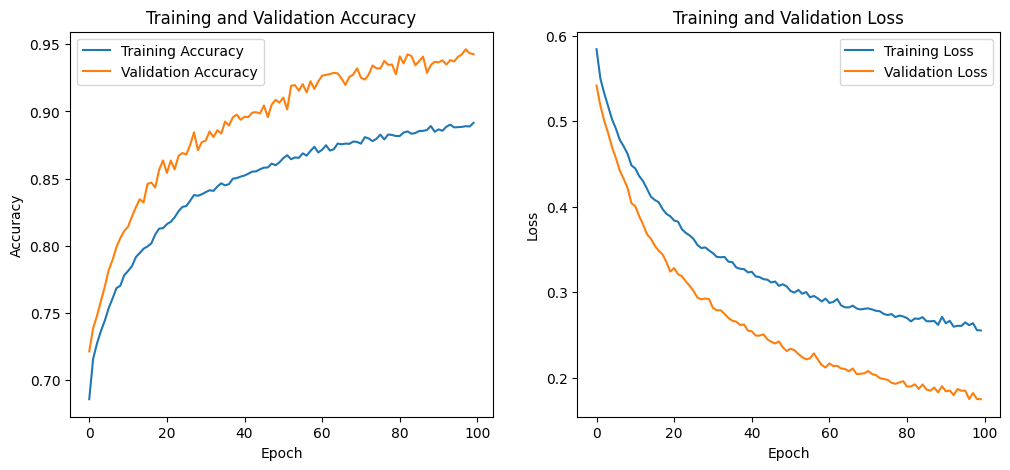

In [5]:
#4. Model Building
input_shape = X_train_processed.shape[1]

# Model neural network
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_shape,)),
    tf.keras.layers.Dense(128, activation='relu', name='hidden_layer_1'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu', name='hidden_layer_2'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid', name='output_layer')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("\n--- Ringkasan Model TensorFlow ---")
model.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("\n--- Training Model ---")
history = model.fit(
    X_train_processed, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Visualisasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


Evaluasi Model pada Data Testing
Test Loss: 0.1793
Test Accuracy: 0.9428
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      4090
           1       0.91      0.98      0.94      4092

    accuracy                           0.94      8182
   macro avg       0.95      0.94      0.94      8182
weighted avg       0.95      0.94      0.94      8182


--- Confusion Matrix ---


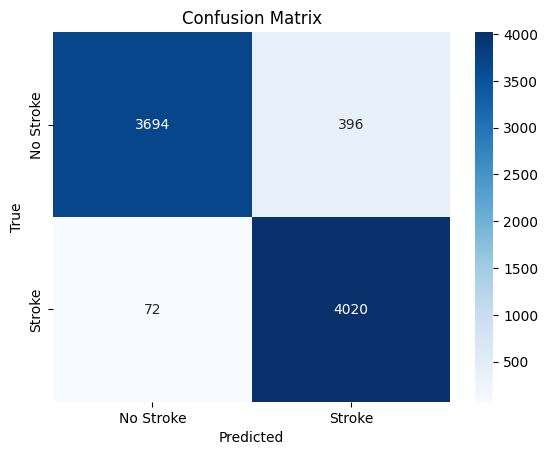

In [6]:
# 5. Model Evaluation
print("\nEvaluasi Model pada Data Testing")
loss, accuracy = model.evaluate(X_test_processed, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

y_pred_proba = model.predict(X_test_processed)
y_pred = (y_pred_proba > 0.5).astype(int)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()



In [7]:
# 6.Simpan Model TFJS Format
MODEL_DIR = 'tfjs_model_stroke'
if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)

keras_model_path = os.path.join(MODEL_DIR, 'keras_model')
tf.saved_model.save(model, keras_model_path)
print(f"Model Keras SavedModel disimpan di: {keras_model_path}")

print("Mengkonversi Model ke Format TFJS")
try:
    tfjs_output_path = os.path.join(MODEL_DIR, 'tfjs_output')
    tfjs.converters.convert_tf_saved_model(
        keras_model_path,
        tfjs_output_path
    )
    print(f"Model berhasil dikonversi dan disimpan di: {tfjs_output_path}")
    print("dapat menggunakan model ini di JavaScript dengan TensorFlow.js.")
except Exception as e:
    print(f"Gagal mengkonversi model ke TFJS: {e}")
    print("Model Keras tetap disimpan di: " + keras_model_path)

print("Informasi Preprocessing untuk TFJS")
print("Saat menggunakan model ini di TFJS (JavaScript),perlu melakukan preprocessing yang sama.")
print("Ini berarti fitur numerik harus di-scale dan fitur kategorikal di-one-hot encode.")

# Dapatkan scaler dan one-hot encoder dari preprocessor
scaler = preprocessor.named_transformers_['num']
ohe = preprocessor.named_transformers_['cat']

# Simpan mean dan std dari StandardScaler
if hasattr(scaler, 'mean_') and hasattr(scaler, 'scale_'):
    print(f"\nMean untuk fitur numerik ({numerical_features}): {scaler.mean_.tolist()}")
    print(f"Std untuk fitur numerik ({numerical_features}): {scaler.scale_.tolist()}")
else:
    print("Tidak dapat mengambil mean dan std dari numerical scaler.")

# Simpan nama kategori dari OneHotEncoder
if hasattr(ohe, 'categories_'):
    print(f"\nKategori untuk fitur kategorikal ({categorical_features}):")
    for i, cat_name in enumerate(categorical_features):
        print(f"  {cat_name}: {ohe.categories_[i].tolist()}")
else:
    print("Tidak dapat mengambil kategori dari OneHotEncoder.")

# Mendapatkan urutan nama fitur setelah preprocessing (ini sangat penting untuk TFJS)
# Urutan kolom setelah ColumnTransformer: [scaled_numerical_features, one_hot_encoded_features]

# feature_names_after_preprocessing = (
#     list(preprocessor.named_transformers_['num'].get_feature_names_out(numerical_features)) +
#     list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
# )
# print("\nUrutan fitur input yang diharapkan oleh model (setelah preprocessing):")
# print(feature_names_after_preprocessing)

Model Keras SavedModel disimpan di: tfjs_model_stroke/keras_model
Mengkonversi Model ke Format TFJS
Model berhasil dikonversi dan disimpan di: tfjs_model_stroke/tfjs_output
dapat menggunakan model ini di JavaScript dengan TensorFlow.js.
Informasi Preprocessing untuk TFJS
Saat menggunakan model ini di TFJS (JavaScript),perlu melakukan preprocessing yang sama.
Ini berarti fitur numerik harus di-scale dan fitur kategorikal di-one-hot encode.

Mean untuk fitur numerik (['age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']): [51.320072111712044, 0.21367678063983866, 0.1266232774162007, 0.8189873804503927, 3.4587038225318545, 0.514376508693128, 121.92625232988053, 30.407764231368592, 0.48797628869129467]
Std untuk fitur numerik (['age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']): [21.61738797468606, 0.4099012247544925, 0.332550481